In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def get_relative_arrays(adult_female, adult_male, pup_female, pup_male, behavior):

    adult = np.vstack((adult_female, adult_male))
    pup = np.vstack((pup_female, pup_male))
    
    # adults_c2 = np.mean((adult[0,13], adult[3,13]), axis = 0)
    # adults_c3 = np.mean((adult[1,13], adult[4,13]), axis = 0)
    # adults_c4 = np.mean((adult[2,13], adult[5,13]), axis = 0)

    adults_c2 = np.mean(np.mean((adult[0,:], adult[3,:]), axis = 0))
    adults_c3 = np.mean(np.mean((adult[1,:], adult[4,:]), axis = 0))
    adults_c4 = np.mean(np.mean((adult[2,:], adult[5,:]), axis = 0))

    pups_c2 = np.empty((4, 14))
    pups_c2[0, :] = pup[0, :]
    pups_c2[1, :] = pup[1, :]
    pups_c2[2, :] = pup[9, :]
    pups_c2[3, :] = pup[10, :]

    pups_c3 = np.empty((4, 14))
    pups_c3[0, :] = pup[2, :]
    pups_c3[1, :] = pup[3, :]
    pups_c3[2, :] = pup[4, :]
    pups_c3[3, :] = pup[11, :]

    pups_c4 = np.empty((4, 14))
    pups_c4[0, :] = pup[5, :]
    pups_c4[1, :] = pup[6, :]
    pups_c4[2, :] = pup[7, :]
    pups_c4[3, :] = pup[8, :]

    c2 = pups_c2 / adults_c2
    c3 = pups_c3 / adults_c3
    c4 = pups_c4 / adults_c4

    mean = np.mean(np.vstack((c2, c3, c4)), axis = 0)
    std = np.std(np.vstack((c2, c3, c4)), axis = 0)
    sem = stats.sem(np.vstack((c2, c3, c4)), axis = 0)
    
    # np.save(f'/Users/lisadiez/Downloads/figures/fig2/npy files/pca-umap/{behavior}.npy', np.vstack((c2,c3,c4)))
    
    return mean, sem, std

In [8]:
#
root_dir = '/home/cat/code/gerbil/meta_data/fig3/'
#
adult_female_exploration = np.load(root_dir + 'adult_female_exploration.npy')
adult_male_exploration = np.load(root_dir + 'adult_male_exploration.npy')
pup_female_exploration = np.load(root_dir + 'pup_female_exploration.npy')
pup_male_exploration = np.load(root_dir + 'pup_male_exploration.npy')

mean_exploration, sem_exploration, std_exploration = get_relative_arrays(adult_female_exploration, adult_male_exploration,
                                                        pup_female_exploration, pup_male_exploration,
                                                        'exploration')

In [13]:

adult_female_distance = np.load(root_dir + 'adult_female_distance.npy')
adult_male_distance = np.load(root_dir + 'adult_male_distance.npy')
pup_female_distance = np.load(root_dir + 'pup_female_distance.npy')
pup_male_distance = np.load(root_dir + 'pup_male_distance.npy')

mean_distance, sem_distance, std_distance = get_relative_arrays(adult_female_distance, adult_male_distance,
                                                  pup_female_distance, pup_male_distance,
                                                  'distance')

In [10]:
adult_female_food = np.load(root_dir + 'adult_female_food.npy')
adult_male_food = np.load(root_dir + 'adult_male_food.npy')
pup_female_food = np.load(root_dir + 'pup_female_food.npy')
pup_male_food = np.load(root_dir + 'pup_male_food.npy')

mean_food, sem_food, std_food = get_relative_arrays(adult_female_food, adult_male_food,
                                          pup_female_food, pup_male_food,
                                          'food')

In [11]:
adult_female_water = np.load(root_dir + 'adult_female_water.npy')
adult_male_water = np.load(root_dir + 'adult_male_water.npy')
pup_female_water = np.load(root_dir + 'pup_female_water.npy')
pup_male_water = np.load(root_dir + 'pup_male_water.npy')

mean_water, sem_water, std_water = get_relative_arrays(adult_female_water, adult_male_water,
                                            pup_female_water, pup_male_water,
                                            'water')

Text(0.5, 1.0, 'Comparison of Pup Behavior to the Average Adult')

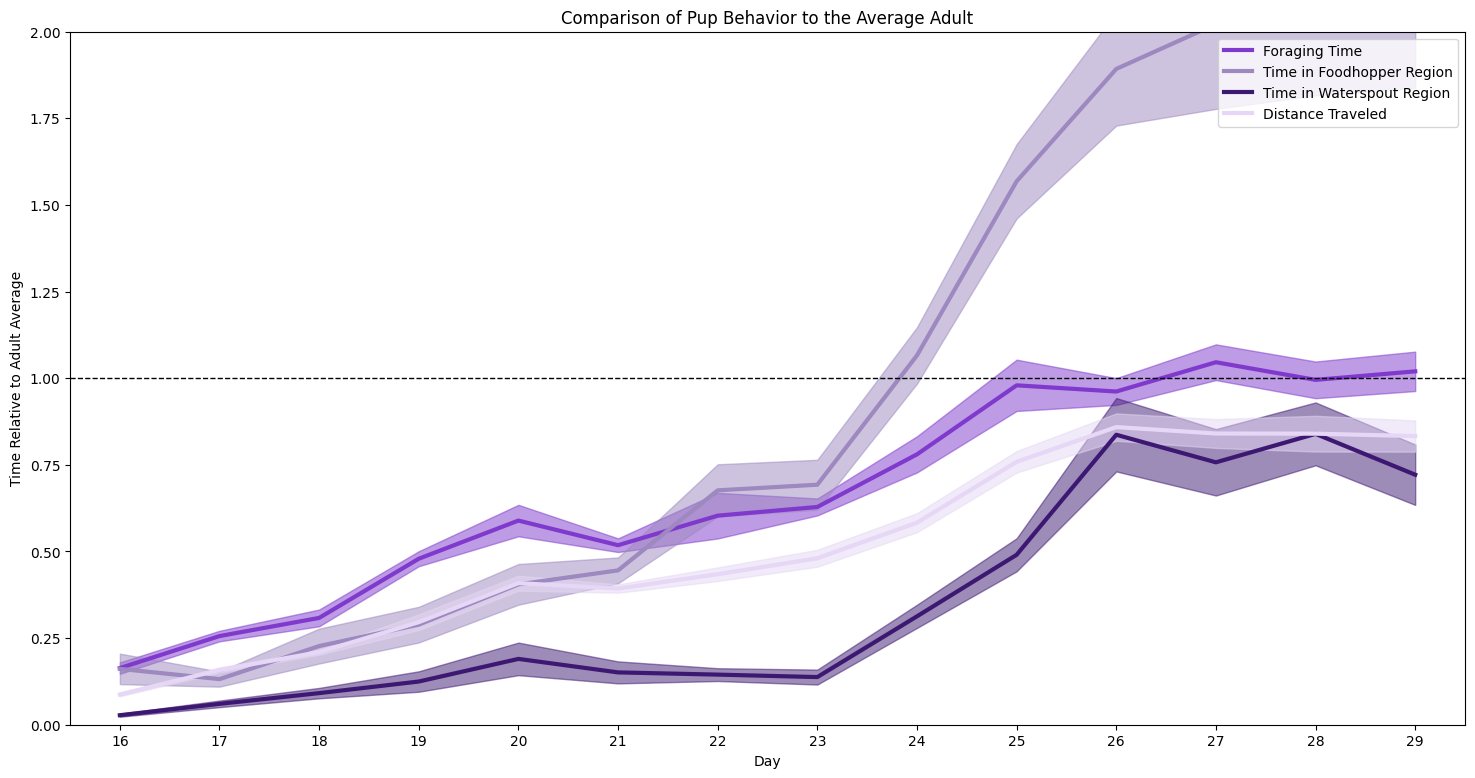

In [15]:
plt.figure(figsize = (18,9))

days = np.arange(16,30)

plt.plot(days, mean_exploration, color = '#7f39cd', linewidth = 3)
plt.plot(days, mean_food, color = '#9d88bf', linewidth = 3)
plt.plot(days, mean_water, color = '#3d1872', linewidth = 3)
plt.plot(days, mean_distance, color = '#e5d7f5', linewidth = 3)

plt.fill_between(days, mean_exploration-sem_exploration, mean_exploration+sem_exploration, color = '#7f39cd', alpha = 0.5)
plt.fill_between(days, mean_food-sem_food, mean_food+sem_food, color = '#9d88bf', alpha = 0.5)
plt.fill_between(days, mean_water-sem_water, mean_water+sem_water, color = '#3d1872', alpha = 0.5)
plt.fill_between(days, mean_distance-sem_distance, mean_distance+sem_distance, color = '#e5d7f5', alpha = 0.5)

plt.hlines(1, 15.5, 29.5, linestyles = 'dashed', color = 'black', linewidth = 1)

plt.xticks(days)

plt.ylim(0,2)
plt.xlim(15.5,29.5)

plt.legend(['Foraging Time', 'Time in Foodhopper Region', 'Time in Waterspout Region', 'Distance Traveled'])

plt.ylabel('Time Relative to Adult Average')
plt.xlabel('Day')

plt.title('Comparison of Pup Behavior to the Average Adult')

#plt.savefig('/Users/lisadiez/Downloads/all_cohorts_autonomy.svg')

In [94]:
adult_female_huddling = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/adult_female_huddling.npy')
adult_male_huddling = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/adult_male_huddling.npy')
pup_female_huddling = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/pup_female_huddling.npy')
pup_male_huddling = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/pup_male_huddling.npy')

mean_huddling, sem_huddling = get_relative_arrays(adult_female_huddling, adult_male_huddling,
                                                  pup_female_huddling, pup_male_huddling,
                                                  'huddling')

In [95]:
adult_female_exits = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/adult_female_exits.npy')
adult_male_exits = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/adult_male_exits.npy')
pup_female_exits = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/pup_female_exits.npy')
pup_male_exits = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/pup_male_exits.npy')

mean_exits, sem_exits = get_relative_arrays(adult_female_exits, adult_male_exits,
                                            pup_female_exits, pup_male_exits,
                                            'exits')

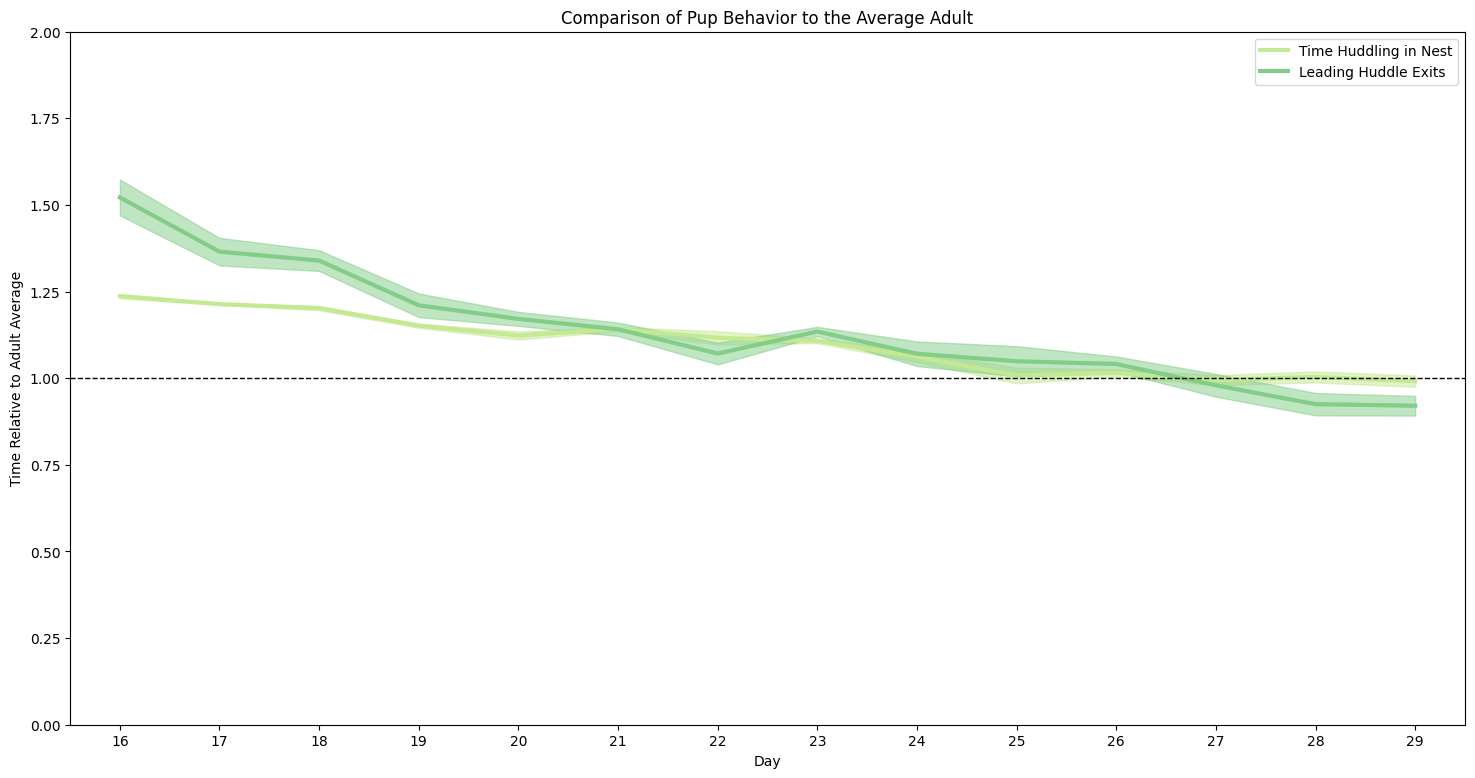

In [96]:
plt.figure(figsize = (18,9))

days = np.arange(16,30)

plt.plot(days, mean_huddling, color = '#c5e892', linewidth = 3)
plt.plot(days, mean_exits, color = '#82cd88', linewidth = 3)

plt.fill_between(days, mean_huddling-sem_huddling, mean_huddling+sem_huddling, color = '#c5e892', alpha = 0.5)
plt.fill_between(days, mean_exits-sem_exits, mean_exits+sem_exits, color = '#82cd88', alpha = 0.5)

plt.hlines(1, 15.5, 29.5, linestyles = 'dashed', color = 'black', linewidth = 1)

plt.xticks(days)

plt.ylim(0,2)
plt.xlim(15.5,29.5)

plt.legend(['Time Huddling in Nest', 'Leading Huddle Exits'])

plt.ylabel('Time Relative to Adult Average')
plt.xlabel('Day')

plt.title('Comparison of Pup Behavior to the Average Adult')

plt.savefig('/Users/lisadiez/Downloads/nest_behaviors_2.svg')

In [30]:
def get_relative_arrays_pairwise(female_p_male_p, female_p, male_p, female_a_female_p, female_a_male_p, male_a_female_p, male_a_male_p, behavior):

    # adults_c2 = adults[0,13]
    # adults_c3 = adults[1,13]
    # adults_c4 = adults[2,13]

    adults_c2 = np.mean(adults[0,:])
    adults_c3 = np.mean(adults[1,:])
    adults_c4 = np.mean(adults[2,:])
    
    pup_pup = np.vstack((female_p_male_p, female_p, male_p))

    pup_pup_c2 = np.empty((6, 14))
    pup_pup_c2[0, :] = pup_pup[0, :]
    pup_pup_c2[1, :] = pup_pup[1, :]
    pup_pup_c2[2, :] = pup_pup[2, :]
    pup_pup_c2[3, :] = pup_pup[3, :]
    pup_pup_c2[4, :] = pup_pup[7, :]
    pup_pup_c2[5, :] = pup_pup[17, :]

    pup_pup_c3 = np.empty((6, 14))
    pup_pup_c3[0, :] = pup_pup[4, :]
    pup_pup_c3[1, :] = pup_pup[5, :]
    pup_pup_c3[2, :] = pup_pup[6, :]
    pup_pup_c3[3, :] = pup_pup[8, :]
    pup_pup_c3[4, :] = pup_pup[9, :]
    pup_pup_c3[5, :] = pup_pup[10, :]

    pup_pup_c4 = np.empty((6, 14))
    pup_pup_c4[0, :] = pup_pup[11, :]
    pup_pup_c4[1, :] = pup_pup[12, :]
    pup_pup_c4[2, :] = pup_pup[13, :]
    pup_pup_c4[3, :] = pup_pup[14, :]
    pup_pup_c4[4, :] = pup_pup[15, :]
    pup_pup_c4[5, :] = pup_pup[16, :]

    pup_pup_c2 = pup_pup_c2 / adults_c2
    pup_pup_c3 = pup_pup_c3 / adults_c3
    pup_pup_c4 = pup_pup_c4 / adults_c4

    mean_pup_pup = np.mean(np.vstack((pup_pup_c2, pup_pup_c3, pup_pup_c4)), axis = 0)
    std_pup_pup = np.std(np.vstack((pup_pup_c2, pup_pup_c3, pup_pup_c4)), axis = 0)
    sem_pup_pup = stats.sem(np.vstack((pup_pup_c2, pup_pup_c3, pup_pup_c4)), axis = 0)
    
    # np.save(f'/Users/lisadiez/Downloads/figures/fig2/npy files/pca-umap/{behavior}_pup_pup.npy', np.vstack((pup_pup_c2,pup_pup_c3,pup_pup_c4)))
    
    adult_pup = np.vstack((female_a_female_p, female_a_male_p, male_a_female_p, male_a_male_p))
    
    adult_pup_c2 = np.empty((8, 14))
    adult_pup_c2[0, :] = adult_pup[0, :]
    adult_pup_c2[1, :] = adult_pup[1, :]
    adult_pup_c2[2, :] = adult_pup[9, :]
    adult_pup_c2[3, :] = adult_pup[10, :]
    adult_pup_c2[4, :] = adult_pup[12, :]
    adult_pup_c2[5, :] = adult_pup[13, :]
    adult_pup_c2[6, :] = adult_pup[21, :]
    adult_pup_c2[7, :] = adult_pup[22, :]
    
    adult_pup_c3 = np.empty((8, 14))
    adult_pup_c3[0, :] = adult_pup[2, :]
    adult_pup_c3[1, :] = adult_pup[3, :]
    adult_pup_c3[2, :] = adult_pup[4, :]
    adult_pup_c3[3, :] = adult_pup[11, :]
    adult_pup_c3[4, :] = adult_pup[14, :]
    adult_pup_c3[5, :] = adult_pup[15, :]
    adult_pup_c3[6, :] = adult_pup[16, :]
    adult_pup_c3[7, :] = adult_pup[23, :]
    
    adult_pup_c4 = np.empty((8, 14))
    adult_pup_c4[0, :] = adult_pup[5, :]
    adult_pup_c4[1, :] = adult_pup[6, :]
    adult_pup_c4[2, :] = adult_pup[7, :]
    adult_pup_c4[3, :] = adult_pup[8, :]
    adult_pup_c4[4, :] = adult_pup[17, :]
    adult_pup_c4[5, :] = adult_pup[18, :]
    adult_pup_c4[6, :] = adult_pup[19, :]
    adult_pup_c4[7, :] = adult_pup[20, :]

    adult_pup_c2 = adult_pup_c2 / adults_c2
    adult_pup_c3 = adult_pup_c3 / adults_c3
    adult_pup_c4 = adult_pup_c4 / adults_c4

    mean_adult_pup = np.mean(np.vstack((adult_pup_c2, adult_pup_c3, adult_pup_c4)), axis = 0)
    std_adult_pup = np.std(np.vstack((adult_pup_c2, adult_pup_c3, adult_pup_c4)), axis = 0)
    sem_adult_pup = stats.sem(np.vstack((adult_pup_c2, adult_pup_c3, adult_pup_c4)), axis = 0)
    
    # np.save(f'/Users/lisadiez/Downloads/figures/fig2/npy files/pca-umap/{behavior}_adult_pup.npy', np.vstack((adult_pup_c2,adult_pup_c3,adult_pup_c4)))
    
    return mean_pup_pup, sem_pup_pup, std_pup_pup, mean_adult_pup, sem_adult_pup, std_adult_pup

In [31]:
adults = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/adults_pairwise.npy')
female_a_female_p = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/femaleadult_femalepup_pairwise.npy')
female_a_male_p = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/femaleadult_malepup_pairwise.npy')
female_p = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/femalepup_femalepup_pairwise.npy')
female_p_male_p = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/femalepup_malepup_pairwise.npy')
male_a_female_p = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/maleadult_femalepup_pairwise.npy')
male_a_male_p = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/maleadult_malepup_pairwise.npy')
male_p = np.load('/Users/lisadiez/Downloads/figures/fig3/npy files/malepup_malepup_pairwise.npy')

mean_pup_pup, sem_pup_pup, std_pup_pup, mean_adult_pup, sem_adult_pup, std_adult_pup = get_relative_arrays_pairwise(female_p_male_p, 
                                                                                        female_p, male_p, 
                                                                                        female_a_female_p, 
                                                                                        female_a_male_p, 
                                                                                        male_a_female_p, 
                                                                                        male_a_male_p,
                                                                                        'pairwise')

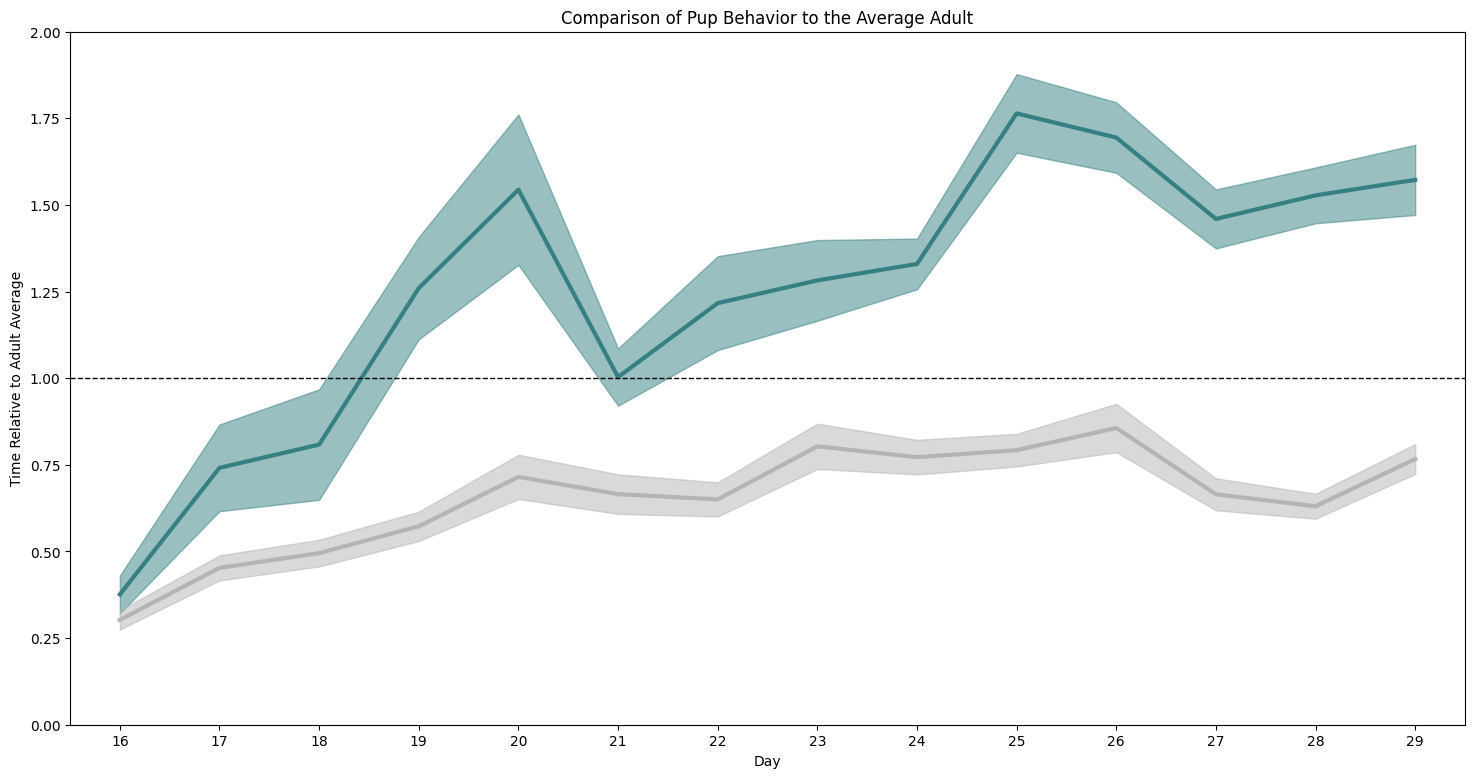

In [88]:
plt.figure(figsize = (18,9))

days = np.arange(16,30)

plt.plot(days, mean_pup_pup, color = '#368083', linewidth = 3)
plt.plot(days, mean_adult_pup, color = '#b4b4b4', linewidth = 3)

plt.fill_between(days, mean_pup_pup-sem_pup_pup, mean_pup_pup+sem_pup_pup, color = '#368083', alpha = 0.5)
plt.fill_between(days, mean_adult_pup-sem_adult_pup, mean_adult_pup+sem_adult_pup, color = '#b4b4b4', alpha = 0.5)

plt.hlines(1, 15.5, 29.5, linestyles = 'dashed', color = 'black', linewidth = 1)

plt.xticks(days)
# plt.yticks(np.arange(0,3.5,0.1))

plt.ylim(0,2)
plt.xlim(15.5,29.5)

plt.ylabel('Time Relative to Adult Average')
plt.xlabel('Day')

plt.title('Comparison of Pup Behavior to the Average Adult')

plt.savefig('/Users/lisadiez/Downloads/pairwise_2.svg')

In [46]:
# adult_pup = np.load('/Users/lisadiez/Downloads/figures/fig2/npy files/pca-umap/adult_pup_approaches.npy')
pup_adult = np.load('/Users/lisadiez/Downloads/figures/fig2/npy files/pup_adult_approaches.npy')
pup_pup = np.load('/Users/lisadiez/Downloads/figures/fig2/npy files/pup_pup_approaches.npy')

In [47]:
def bedding_change(arr):
    
    arr[:, 8] = (arr[:, 7] + arr[:, 9]) / 2 
    arr[:, 2] = (arr[:, 1] + arr[:, 3]) / 2 
            
    return arr

In [48]:
pup_adult = bedding_change(pup_adult)
pup_pup = bedding_change(pup_pup)

In [19]:
np.save('/Users/lisadiez/Downloads/figures/fig2/npy files/pca-umap/p29/pup_adult_approaches.npy', pup_adult)
np.save('/Users/lisadiez/Downloads/figures/fig2/npy files/pca-umap/p29/pup_pup_approaches.npy', pup_pup)

In [51]:
# mean_adult_pup = np.mean(adult_pup, axis = 0)
# sem_adult_pup = stats.sem(adult_pup, axis = 0)

mean_pup_adult = np.mean(pup_adult, axis = 0)
std_pup_adult = np.std(pup_adult, axis = 0)
sem_pup_adult = stats.sem(pup_adult, axis = 0)

mean_pup_pup = np.mean(pup_pup, axis = 0)
std_pup_pup = np.std(pup_pup, axis = 0)
sem_pup_pup = stats.sem(pup_pup, axis = 0)

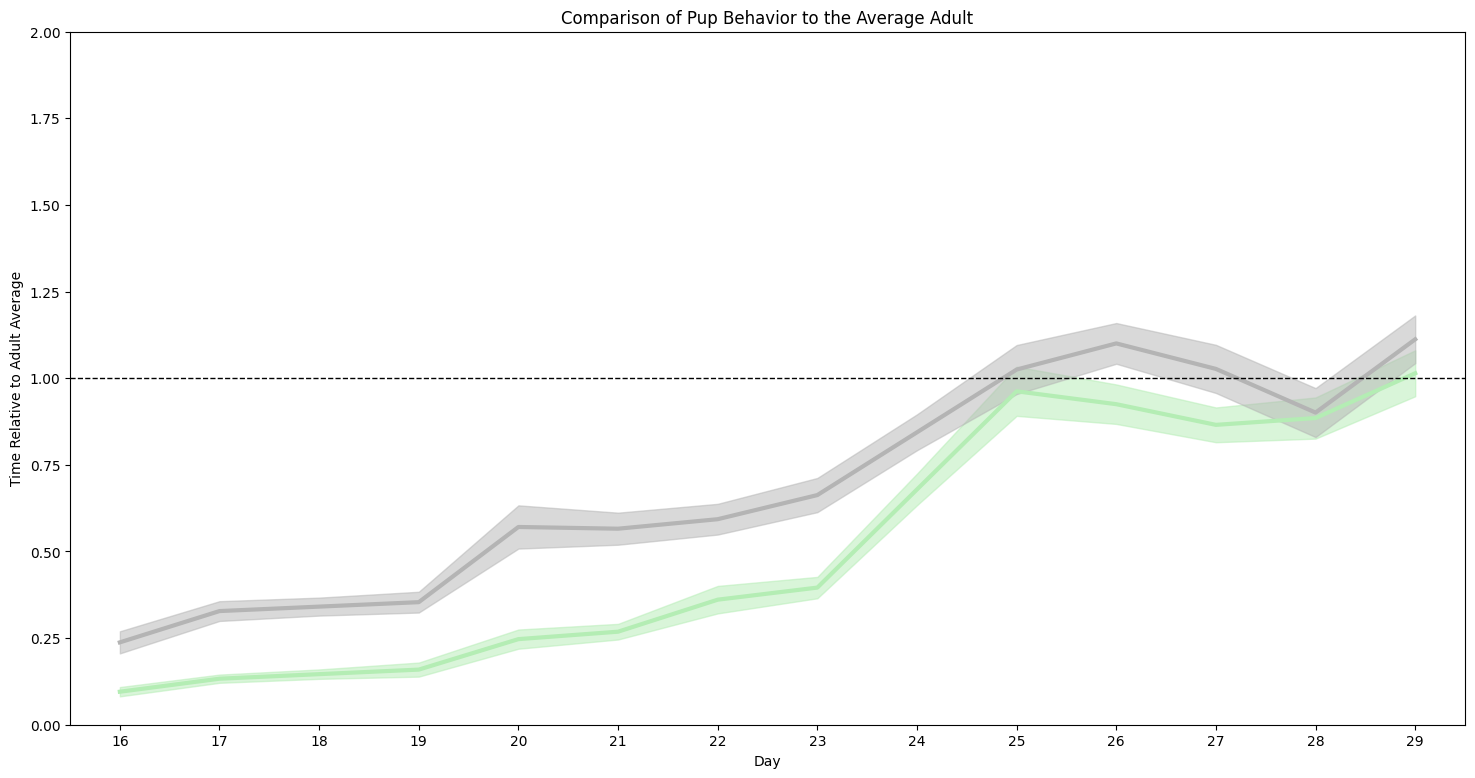

In [24]:
plt.figure(figsize = (18,9))

days = np.arange(16,30)

plt.plot(days, mean_pup_pup, color = '#b4edb4', linewidth = 3)
# plt.plot(days, mean_adult_pup, color = '#b4b4b4', linewidth = 3)
plt.plot(days, mean_pup_adult, color = '#b4b4b4', linewidth = 3)

plt.fill_between(days, mean_pup_pup + sem_pup_pup, mean_pup_pup - sem_pup_pup, color = '#b4edb4', alpha = 0.5)
# plt.fill_between(days, mean_adult_pup + sem_adult_pup, mean_adult_pup - sem_adult_pup, color = '#b4b4b4', alpha = 0.5)
plt.fill_between(days, mean_pup_adult + sem_pup_adult, mean_pup_adult - sem_pup_adult, color = '#b4b4b4', alpha = 0.5)

plt.hlines(1, 15.5, 29.5, linestyles = 'dashed', color = 'black', linewidth = 1)

plt.xticks(days)
# plt.yticks(np.arange(0,3.5,0.1))

plt.ylim(0,2)
plt.xlim(15.5,29.5)

plt.ylabel('Time Relative to Adult Average')
plt.xlabel('Day')

plt.title('Comparison of Pup Behavior to the Average Adult')

plt.savefig('/Users/lisadiez/Downloads/approaches.svg')

In [57]:
np.mean(mean_pup_pup[-4:]*100), np.mean(std_pup_pup[:-4]*100)

(92.24487526926552, 17.538824742271323)

In [58]:
np.mean(mean_pup_adult[-4:]*100), np.mean(std_pup_adult[-4:]*100)

(103.51233844069208, 32.09741057618683)